- uptick in searches --> proxy for interest?
- April 24 Rememberance Day 
- google trend data shows obvious peaks from march 30-april 30 every year for 5 years 
- 2015 was 100 years, 2025 was 110 years --> weave into the story 

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import plotly.express as px
from collections import Counter

----

* Hi Sose! I ran a query for tweets containing `#1915neveragain` in the Wharton/ASC Historical Tweet archive
  - see https://research-it.wharton.upenn.edu/data/tweet-database/
  - It is a sample collected from Twitter from Apr 2012 to Nov 2022 (so not currrent!)
  - It is a sample of about 1% of the tweets published each day
* In the `data` folder is a CSV file `twitter_sample_#1915neveragain.csv`

In [70]:
twitter_df = pd.read_csv('data/twitter_sample_#1915neveragain.csv')

In [71]:
twitter_df.shape

(449, 63)

* There aren't loads of tweets with `#1915neveragain` in the sample so maybe we want to try some additional searches?

* But you can see the fields that are included
  - `created_at` and `timestamp`
  - `extended_full_text`


In [72]:
twitter_df.sample(20)

,created_at,timestamp_ms,id,extended_full_text,user_id,user_screen_name,user_name,user_followers_count,user_location,user_created_at,...,rt_source,rt_created_at,rt_user_screen_name,lat_float,long_float,hour,year,month,day,date
340,Fri Oct 09 05:32:09 +0000 2020,1602221529664,1314438481213489155,#1915neveragain #DefendArmenia #ArmeniaStrong ...,9.980966e+17,sosehh,Sose,49,"New York, NY",Sun May 20 07:02:32 +0000 2018,...,NaN,NaN,NaN,NaN,NaN,5,2020,10,9,10/09/2020
222,Sun Apr 24 22:30:19 +0000 2016,1461537019000,724425276147523585,#armeniangenocide #1915neveragain #losangeles ...,NaN,hokidsirem,George Yaghoubian,213,"Los Angeles, CA",Tue Jun 21 01:13:33 +0000 2011,...,NaN,NaN,NaN,NaN,NaN,22,2016,4,24,04/24/2016
261,Fri Mar 17 00:06:31 +0000 2017,1489709191000,842587929855721474,RT @613_carolyne: CSUN Prof. brings in Young T...,NaN,tamazyan_roman,roman tamazyan,127,NaN,Sun Aug 09 06:08:00 +0000 2015,...,NaN,Thu Nov 10 18:55:43 +0000 2016,613_carolyne,NaN,NaN,0,2017,3,17,03/17/2017
270,Mon Apr 24 16:16:42 +0000 2017,1493050602000,856602823378718720,#RecognizeTheArmenianGenocide #ArmenianGenocid...,NaN,xorita_,Rita,159,NaN,Sun Mar 15 19:54:10 +0000 2015,...,NaN,NaN,NaN,NaN,NaN,16,2017,4,24,04/24/2017
130,Tue Apr 21 18:44:54 +0000 2015,1429641894000,590647425787912192,"RT @mhovakimian: ARMENIANS united, we will nev...",NaN,emmstter_,Emma,104,NaN,Thu Mar 27 15:51:48 +0000 2014,...,NaN,Tue Apr 21 18:41:43 +0000 2015,mhovakimian,NaN,NaN,18,2015,4,21,04/21/2015
204,Sat Apr 25 00:53:28 +0000 2015,1429923208000,591827342214856704,RT @__maaarrr__: Thank you to all the Non-Arme...,NaN,ediiiitpenguin,ediiiit,304,NaN,Tue Apr 15 01:16:15 +0000 2014,...,NaN,Sat Apr 25 00:40:03 +0000 2015,__maaarrr__,NaN,NaN,0,2015,4,25,04/25/2015
380,Mon Oct 12 14:07:56 +0000 2020,1602511676662,1315655445927784449,ARMENIANS WANT PEACE! #1915neveragain #DefendA...,1.314416e+18,AvedisianMano,mano avedisian,4,NaN,Fri Oct 09 04:05:12 +0000 2020,...,NaN,NaN,NaN,NaN,NaN,14,2020,10,12,10/12/2020
267,Sat Apr 22 06:06:37 +0000 2017,1492841197000,855724515157917696,Just watched The Promiseâ™¥ï¸�amazing filmðŸŽ¥...,NaN,wfgsonia7_sonia,GeeSon,199,NaN,Wed Aug 14 15:51:07 +0000 2013,...,NaN,NaN,NaN,NaN,NaN,6,2017,4,22,04/22/2017
176,Fri Apr 24 20:20:01 +0000 2015,1429906801000,591758526281699328,RT @thesethbishop: 100 years has passed. Remem...,NaN,5sosupdates_dm,we â�¤ï¸� 5sos,2143,NZ AUS USA UK,Wed Jan 07 17:20:32 +0000 2015,...,NaN,Fri Apr 24 19:43:09 +0000 2015,thesethbishop,NaN,NaN,20,2015,4,24,04/24/2015
248,Mon Apr 25 04:41:00 +0000 2016,1461559260000,724518561667002368,"RT @KutieNameKim: ""We bleed Red, blue, and ora...",NaN,KIMMYDOLLIES,halleâ™¡,2417,UK,Fri Jul 31 03:14:09 +0000 2015,...,NaN,Sun Apr 24 20:04:45 +0000 2016,KutieNameKim,NaN,NaN,4,2016,4,25,04/25/2016


* To use as a timeseries we need to convert the `timestamp_ms` number into a `datetime` object

In [73]:
twitter_df['date']=pd.to_datetime(twitter_df['timestamp_ms'], unit='ms', utc=True)

* Then you can resample (e.g. to tweets by day or by week or by month etc)
* And create a line plot

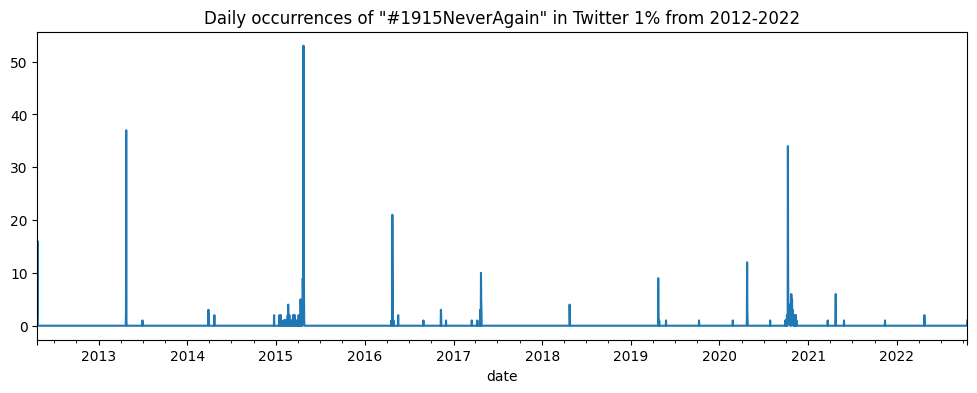

In [81]:
twitter_df.set_index('date').resample('1D').size().plot(figsize=(12,4))
plt.title('Daily occurrences of "#1915NeverAgain" in Twitter 1% from 2012-2022')
plt.show()

* Makes more sense to group by week (as the Google Trends data is at the week level)

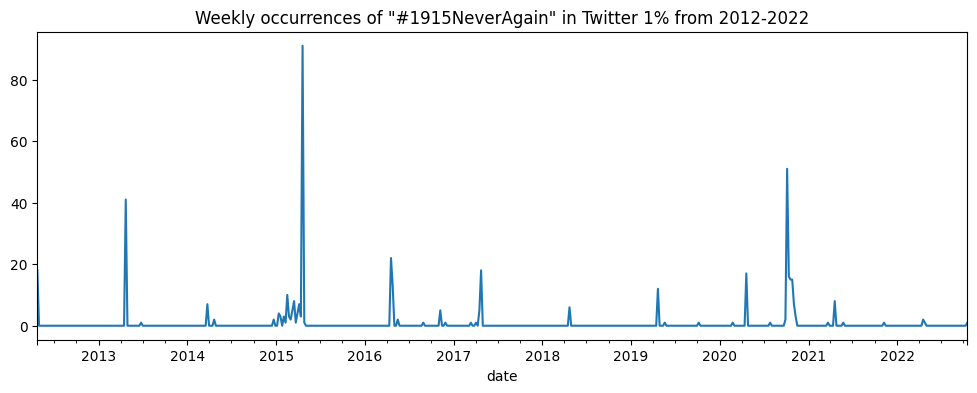

In [79]:
twitter_df.set_index('date').resample('7D').size().plot(figsize=(12,4))
plt.title('Weekly occurrences of "#1915NeverAgain" in Twitter 1% from 2012-2022')
plt.show()

#### Using the `TurkeyFailed` sample from Twitter

In [76]:
turkeyfailed_df = pd.read_csv('data/twitter_sample_turkeyfailed.csv')
turkeyfailed_df['date']=pd.to_datetime(turkeyfailed_df['timestamp_ms'], unit='ms', utc=True)
turkeyfailed_df.shape

(773, 63)

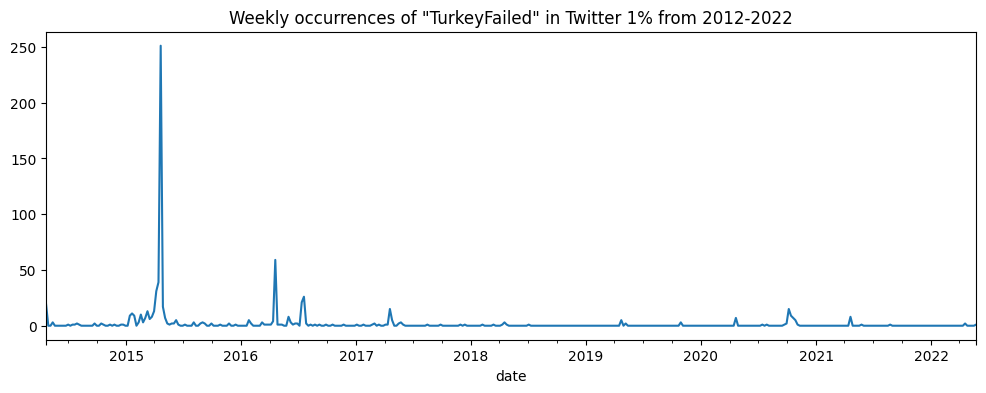

In [80]:
turkeyfailed_df.set_index('date').resample('7D').size().plot(figsize=(12,4))
plt.title('Weekly occurrences of "TurkeyFailed" in Twitter 1% from 2012-2022')
plt.show()

* Plots give you a way of identifying patterns and peaks and trends etc.
* You can then delve into the data for specific periods or calculate counts etc.

#### Notes of Google Trends data

* Because measure of interest is relative to the timespan searched it can be tricky to figure out how to interpret and use different timespans.

* In `data/gtrends_armenian_genocide` I put yearly files extracted using `pytrends` with `YEAR-01-01 YEAR-12-31` as argument. 

In [3]:
ag_gtrends_files = glob.glob('data/gtrends_armenian_genocide/*.csv')
len(ag_gtrends_files)

15

* We can combine all of these into a single data frame and then add a `datetime` and other date fields

In [82]:
year_data = [pd.read_csv(fname) for fname in ag_gtrends_files]
combined_df = pd.concat(year_data).reset_index().drop(columns='index')

In [83]:
combined_df=combined_df.assign(
    dt=pd.to_datetime(combined_df['date']),
    year=lambda x: x['dt'].dt.year,
    MD=lambda x: x['date'].str[-5:],
    doy=lambda x: x['dt'].dt.day_of_year,
    week_num=lambda x: x['dt'].dt.isocalendar()['week']
)

In [84]:
combined_df.columns

Index(['date', 'Armenian genocide', 'dt', 'year', 'MD', 'doy', 'week_num'], dtype='str')

In [85]:
combined_df.head()

,date,Armenian genocide,dt,year,MD,doy,week_num
0,2012-01-01,10,2012-01-01,2012,01-01,1,52
1,2012-01-08,12,2012-01-08,2012,01-08,8,1
2,2012-01-15,13,2012-01-15,2012,01-15,15,2
3,2012-01-22,35,2012-01-22,2012,01-22,22,3
4,2012-01-29,17,2012-01-29,2012,01-29,29,4


In [106]:
combined_df.to_csv('data/gtrends_armenian_genocide_2012-2026.csv', index=False)

* This combined file is saved to `data/gtrends_armenian_genocide_2012-2026.csv` so you can use in your blog post without having to combine the yearly ones.

* Can create a single timeline plot

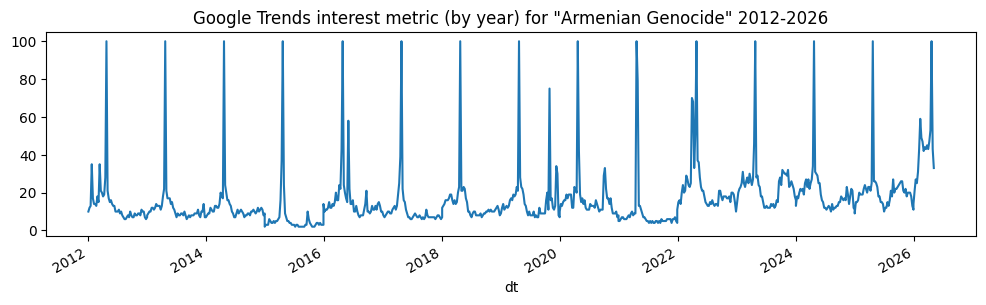

In [86]:
combined_df.set_index('dt')['Armenian genocide'].plot(figsize=(12,3))
plt.title('Google Trends interest metric (by year) for "Armenian Genocide" 2012-2026')
plt.show()

* This reveals clearly the yearly cycles around April 24
* Also shows some interesting divergences in certain years, e.g. 2019, 2022 etc.

* To create a plot with week of the year on x-axis and a line for each year
* Transform data from long to wide data frame

In [87]:
wide_df=combined_df.pivot_table(values="Armenian genocide", index=["week_num"], columns=["year"])

In [88]:
wide_df

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
week_num,,,,,,,,,,,,,,,
1,12.000000,9.0,8.0,3.0,11.0,7.0,13.0,12.0,14.0,6.0,16.0,20.000000,18.0,15.0,21.0
2,13.000000,10.0,9.0,3.0,11.0,8.0,14.0,14.0,13.0,7.0,14.0,22.000000,17.0,15.0,27.0
3,35.000000,10.0,9.0,3.0,12.0,9.0,16.0,11.0,15.0,7.0,20.0,23.000000,20.0,16.0,25.0
4,17.000000,12.0,12.0,6.0,15.0,10.0,16.0,12.0,16.0,6.0,24.0,25.000000,22.0,20.0,31.0
5,14.000000,12.0,11.0,5.0,12.0,10.0,16.0,13.0,16.0,6.0,20.0,31.000000,21.0,19.0,43.0
6,14.000000,11.0,10.0,4.0,12.0,9.0,17.0,12.0,19.0,6.0,21.0,25.000000,22.0,19.0,59.0
7,13.000000,12.0,10.0,4.0,14.0,9.0,19.0,13.0,17.0,7.0,29.0,23.000000,19.0,19.0,49.0
8,18.000000,14.0,13.0,5.0,13.0,11.0,19.0,16.0,19.0,8.0,27.0,26.000000,25.0,22.0,47.0
9,15.000000,13.0,13.0,4.0,15.0,12.0,16.0,17.0,19.0,7.0,24.0,28.000000,27.0,24.0,42.0


* This plot is not great for communication but helpful for exploration and identification of patterns

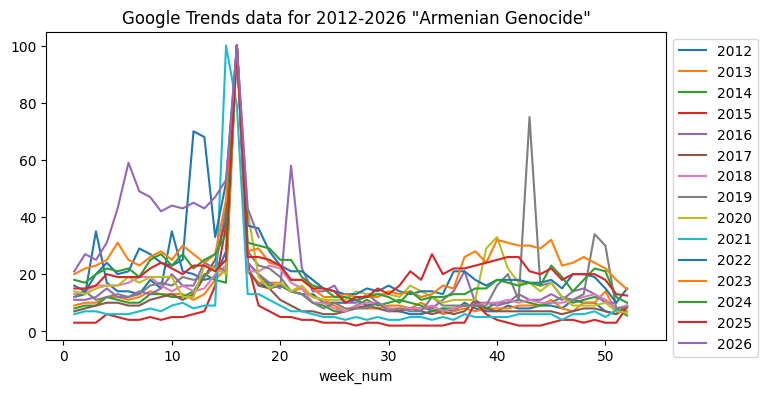

In [90]:
wide_df.plot(figsize=(8,4))
plt.legend(bbox_to_anchor=(1, 1))
plt.title('Google Trends data for 2012-2026 "Armenian Genocide"')
plt.show()

* Notice 2019 has a later in the year peak - why is this?
* I would probably drop 2026 because it is incomplete so the metric is not comparable with other years with 52 points.

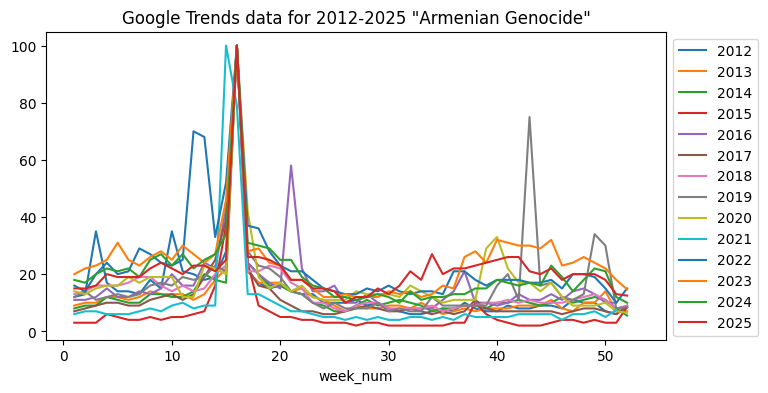

In [96]:
wide_df.drop(columns=2026).plot(figsize=(8,4))
plt.legend(bbox_to_anchor=(1, 1))
plt.title('Google Trends data for 2012-2025 "Armenian Genocide"')
plt.show()

* Some interesting things to look at for 2016 abd 2022? (check the data)
* To investigate this more easily you can create an interactive plot with `plotly`
* And don't need wide form data for that can use `combined_df`

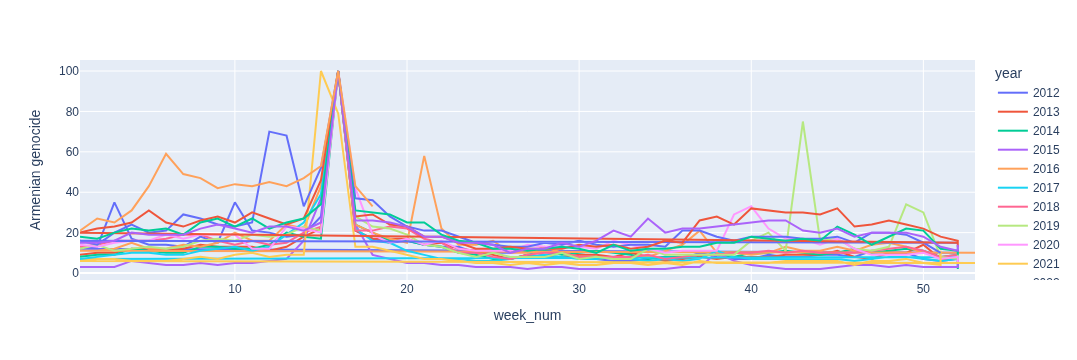

In [105]:
fig=px.line(combined_df, 
            x='week_num', 
            y='Armenian genocide', 
            color='year',
            hover_data=["date"])

fig.show()

### Some addition notes on the Twitter data

* The Twitter datasets have the tweet text in the `extended_full_text` column
* So you can do some simple word counting (maybe focusing on the hashtags?)


In [111]:
twitter_df['hashtags']=twitter_df['extended_full_text'].str.lower().str.findall(r'#\S+')
twitter_df['hashtags']

0      [#1915neveragain, #recognizethearmeniangenocid...
1                                      [#1915neveragain]
2                   [#1915neveragain, #armeniangenocide]
3                                      [#1915neveragain]
4                   [#armeniangenocide, #1915neveragain]
                             ...                        
444    [#genocidioarmenio, #armeniangenocide, #1915ne...
445                                    [#1915neveragain]
446                 [#armeniangenocide, #1915neveragain]
447    [#genocide, #armeniangenocide, #1915, #1915nev...
448    [#armenianlivesmatter, #stopazeriaggression, #...
Name: hashtags, Length: 449, dtype: object

In [115]:
hashtag_cnt = Counter()
_ = twitter_df['hashtags'].apply(lambda l: hashtag_cnt.update(l))

* Look at the top 50 most frequently used hashtags in the `#1915NeverAgain` sample

In [116]:
hashtag_cnt.most_common(50)

[('#1915neveragain', 441),
 ('#armeniangenocide', 205),
 ('#stopaliyev', 67),
 ('#stoperdogan', 60),
 ('#artsakhstrong', 58),
 ('#defendarmenia', 54),
 ('#turkeyfailed', 53),
 ('#armeniastrong', 50),
 ('#stopazerbaijaniaggression', 47),
 ('#sanctionazerbaijan', 38),
 ('#stopazerbaijan', 32),
 ('#stopturkey', 32),
 ('#stopazeriaggression', 30),
 ('#100yearsofdenial', 29),
 ('#sanctionerdogan', 29),
 ('#sanctionaliyev', 29),
 ('#recognizethearmeniangenocide', 24),
 ('#recognizearmeniangenocide', 24),
 ('#recognizeartsakh', 24),
 ('#pilibos100days', 23),
 ('#sanctionturkey', 23),
 ('#peaceforarmenians', 17),
 ('#armenia', 15),
 ('#armenian', 14),
 ('#stopazeriwarcrimes', 14),
 ('#recognizearstakh', 13),
 ('#genocide', 12),
 ('#stopturkeyterrorists', 12),
 ('#neverforget', 9),
 ('#100years', 8),
 ('#1915', 8),
 ('#peaceforarmenia', 7),
 ('#artsakhisarmenia', 7),
 ('#genocidioarmenio', 6),
 ('#100thyearofthegenocide', 6),
 ('#1915neverforget', 6),
 ('#genocidedenial', 6),
 ('#propaganda', 6